# Application Train EDA - Home Credit Default Risk

This notebook performs exploratory data analysis on the `application_train.csv` file.

The objective is to understand which applicant characteristics are associated with repayment difficulty.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
app_train=pd.read_csv("../data/raw/application_train.csv")
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
target = "TARGET"

default_rate = app_train[target].mean()
print(f"Default Rate: {default_rate:.2%}")


Default Rate: 8.07%


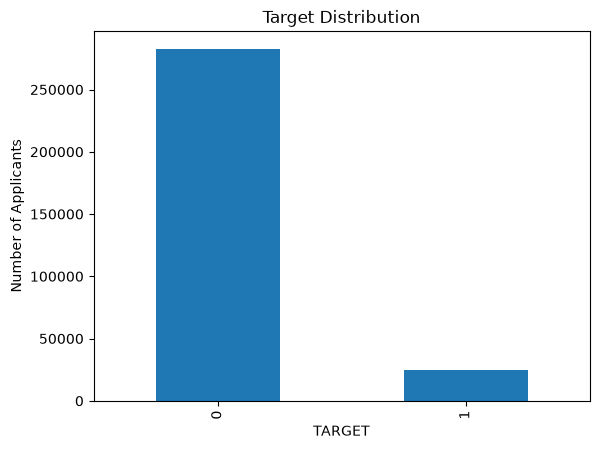

In [5]:
app_train[target].value_counts().plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("TARGET")
plt.ylabel("Number of Applicants")
plt.show()

In [6]:
contract_default = app_train.groupby("NAME_CONTRACT_TYPE")[target].mean().sort_values(ascending=False)

contract_default

NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783
Name: TARGET, dtype: float64

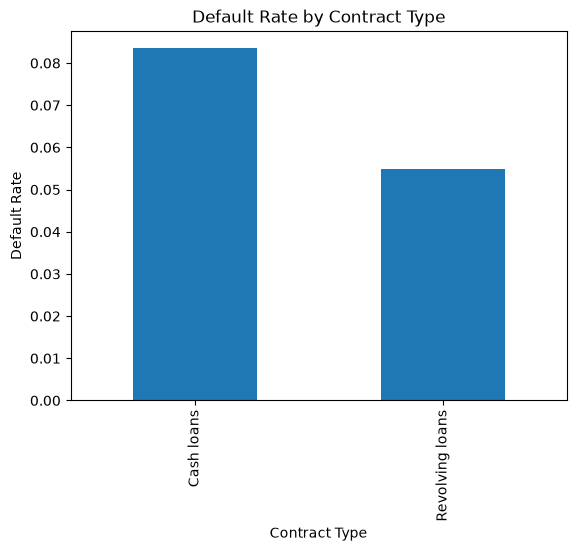

In [7]:
contract_default.plot(kind="bar")

plt.title("Default Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Default Rate")
plt.show()

In [8]:
gender_default = app_train.groupby("CODE_GENDER")[target].mean().sort_values(ascending=False)

gender_default

CODE_GENDER
M      0.101419
F      0.069993
XNA    0.000000
Name: TARGET, dtype: float64

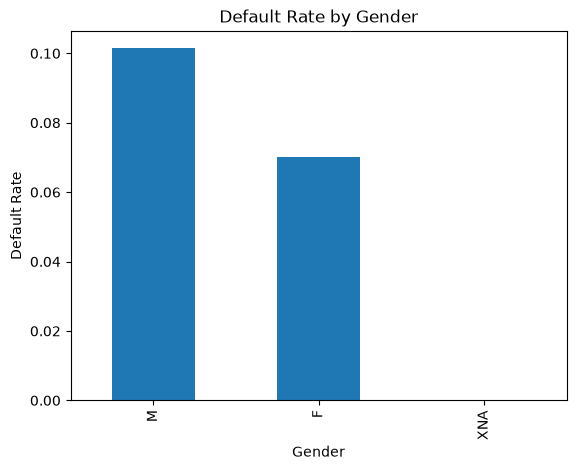

In [9]:
gender_default.plot(kind="bar")

plt.title("Default Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Default Rate")
plt.show()